In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("..")  # go to project root
print(f"cwd: {os.getcwd()}")  # sanity check

cwd: /home/dude-desktop/dev/taming-transformers


In [2]:
import pandas as pd
import numpy as np
import csv
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
RESULTS_CSV = "analysis/results.csv"
FIG_DIR = "analysis/figs"
STANDARD_COLS = [
    "run_name",
    "mIoU_macro",
    "f1_macro",
    "precision_macro",
    "recall_macro",
    "accuracy_macro",
]

def table_3sf(df):
    return df.round(3)

In [4]:
R = pd.read_csv(RESULTS_CSV, quoting=csv.QUOTE_NONNUMERIC)
R

,run_name,ckpt_path,mIoU_macro,accuracy_macro,f1_macro,precision_macro,recall_macro,acc_unlabeled,acc_person,acc_bicycle,...,acc_wall-other,acc_wall-panel,acc_wall-stone,acc_wall-tile,acc_wall-wood,acc_water-other,acc_waterdrops,acc_window-blind,acc_window-other,acc_wood
0,coco_segmentation_ce_loss,analysis/logs/2025-10-01T12-17-48_coco_segment...,0.738424,0.790192,0.816147,0.857616,0.790192,0.893240,0.975127,0.823268,...,0.954025,0.935865,0.910334,0.973672,0.945284,0.963484,0.398698,0.929140,0.957342,0.928822
1,coco_segmentation_bce_loss,analysis/logs/2025-10-01T12-18-14_coco_segment...,0.723861,0.778291,0.803212,0.847983,0.778291,0.904578,0.975154,0.804283,...,0.949198,0.936621,0.914283,0.971289,0.940921,0.951587,0.304488,0.911938,0.961856,0.897355
2,coco_segmentation_ce_dice_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.748511,0.802365,0.825784,0.860769,0.802365,0.901436,0.960015,0.815714,...,0.952559,0.937452,0.933217,0.958994,0.946226,0.956061,0.434010,0.936973,0.947774,0.863489
3,coco_segmentation_focal_g1_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.723710,0.781435,0.805785,0.849064,0.781435,0.885957,0.951253,0.740170,...,0.942871,0.927907,0.930618,0.964017,0.933229,0.949031,0.227377,0.919797,0.923135,0.875373
4,coco_segmentation_focal_g2_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.729700,0.782227,0.808846,0.856277,0.782227,0.882653,0.973313,0.811503,...,0.959985,0.881252,0.871911,0.968499,0.942610,0.962642,0.203984,0.931301,0.951433,0.903157
5,coco_segmentation_focal_g5_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.672012,0.743484,0.769479,0.822827,0.743484,0.498375,0.945617,0.790519,...,0.831414,0.934894,0.904133,0.909554,0.865991,0.917739,0.249256,0.933615,0.945582,0.826733
6,coco_segmentation_focal_g2_acw_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.509513,0.567434,0.604220,0.703344,0.567434,0.914636,0.982492,0.532875,...,0.917045,0.751498,0.756156,0.915747,0.832701,0.916752,0.000000,0.731019,0.847093,0.576458
7,coco_segmentation_focal_g2_log_acw_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.722990,0.769199,0.802064,0.863473,0.769199,0.903230,0.972375,0.786884,...,0.968748,0.935963,0.916664,0.974679,0.948059,0.961934,0.217781,0.923084,0.952551,0.875939
8,coco_segmentation_ce_lovasz_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.727159,0.785056,0.809466,0.849768,0.785056,0.876999,0.961460,0.820427,...,0.925251,0.945789,0.912521,0.921624,0.928513,0.962783,0.350349,0.920397,0.950563,0.877120


### Focal: Best $\gamma$ (gamma)

In [5]:
FOCAL_GAMMA_EXPERIMENTS = [
    "coco_segmentation_focal_g1_loss",
    "coco_segmentation_focal_g2_loss",
    "coco_segmentation_focal_g5_loss",
]

R_focal_gamma = R[R["run_name"].isin(FOCAL_GAMMA_EXPERIMENTS)]
display(R_focal_gamma[STANDARD_COLS])
table_3sf(R_focal_gamma[STANDARD_COLS])

,run_name,mIoU_macro,f1_macro,precision_macro,recall_macro,accuracy_macro
3,coco_segmentation_focal_g1_loss,0.723710,0.805785,0.849064,0.781435,0.781435
4,coco_segmentation_focal_g2_loss,0.729700,0.808846,0.856277,0.782227,0.782227
5,coco_segmentation_focal_g5_loss,0.672012,0.769479,0.822827,0.743484,0.743484


,run_name,mIoU_macro,f1_macro,precision_macro,recall_macro,accuracy_macro
3,coco_segmentation_focal_g1_loss,0.724,0.806,0.849,0.781,0.781
4,coco_segmentation_focal_g2_loss,0.730,0.809,0.856,0.782,0.782
5,coco_segmentation_focal_g5_loss,0.672,0.769,0.823,0.743,0.743


### Focal: Best $\alpha$ (alpha)

In [6]:
FOCAL_ALPHA_EXPERIMENTS = [
    "coco_segmentation_focal_g2_acw_loss",
    "coco_segmentation_focal_g2_log_acw_loss",
]

R_focal_alpha = R[R["run_name"].isin(FOCAL_ALPHA_EXPERIMENTS)]
display(R_focal_alpha[STANDARD_COLS])
table_3sf(R_focal_alpha[STANDARD_COLS])

,run_name,mIoU_macro,f1_macro,precision_macro,recall_macro,accuracy_macro
6,coco_segmentation_focal_g2_acw_loss,0.509513,0.604220,0.703344,0.567434,0.567434
7,coco_segmentation_focal_g2_log_acw_loss,0.722990,0.802064,0.863473,0.769199,0.769199


,run_name,mIoU_macro,f1_macro,precision_macro,recall_macro,accuracy_macro
6,coco_segmentation_focal_g2_acw_loss,0.510,0.604,0.703,0.567,0.567
7,coco_segmentation_focal_g2_log_acw_loss,0.723,0.802,0.863,0.769,0.769


### Overall Performance Comparison

In [7]:
OVERALL_EXPERIMENTS = set(R["run_name"].unique()) - set(FOCAL_GAMMA_EXPERIMENTS) - set(FOCAL_ALPHA_EXPERIMENTS) | {"coco_segmentation_focal_g2_loss"}
R_overall = R[R["run_name"].isin(OVERALL_EXPERIMENTS)]
display(R_overall[STANDARD_COLS])
table_3sf(R_overall[STANDARD_COLS])

,run_name,mIoU_macro,f1_macro,precision_macro,recall_macro,accuracy_macro
0,coco_segmentation_ce_loss,0.738424,0.816147,0.857616,0.790192,0.790192
1,coco_segmentation_bce_loss,0.723861,0.803212,0.847983,0.778291,0.778291
2,coco_segmentation_ce_dice_loss,0.748511,0.825784,0.860769,0.802365,0.802365
4,coco_segmentation_focal_g2_loss,0.729700,0.808846,0.856277,0.782227,0.782227
8,coco_segmentation_ce_lovasz_loss,0.727159,0.809466,0.849768,0.785056,0.785056


,run_name,mIoU_macro,f1_macro,precision_macro,recall_macro,accuracy_macro
0,coco_segmentation_ce_loss,0.738,0.816,0.858,0.790,0.790
1,coco_segmentation_bce_loss,0.724,0.803,0.848,0.778,0.778
2,coco_segmentation_ce_dice_loss,0.749,0.826,0.861,0.802,0.802
4,coco_segmentation_focal_g2_loss,0.730,0.809,0.856,0.782,0.782
8,coco_segmentation_ce_lovasz_loss,0.727,0.809,0.850,0.785,0.785


### Overall mean IoU bar chart

/tmp/ipykernel_18553/134092358.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["run_name"] = df["run_name"].map(HUMAN_READABLE_NAMES).fillna(df["run_name"])


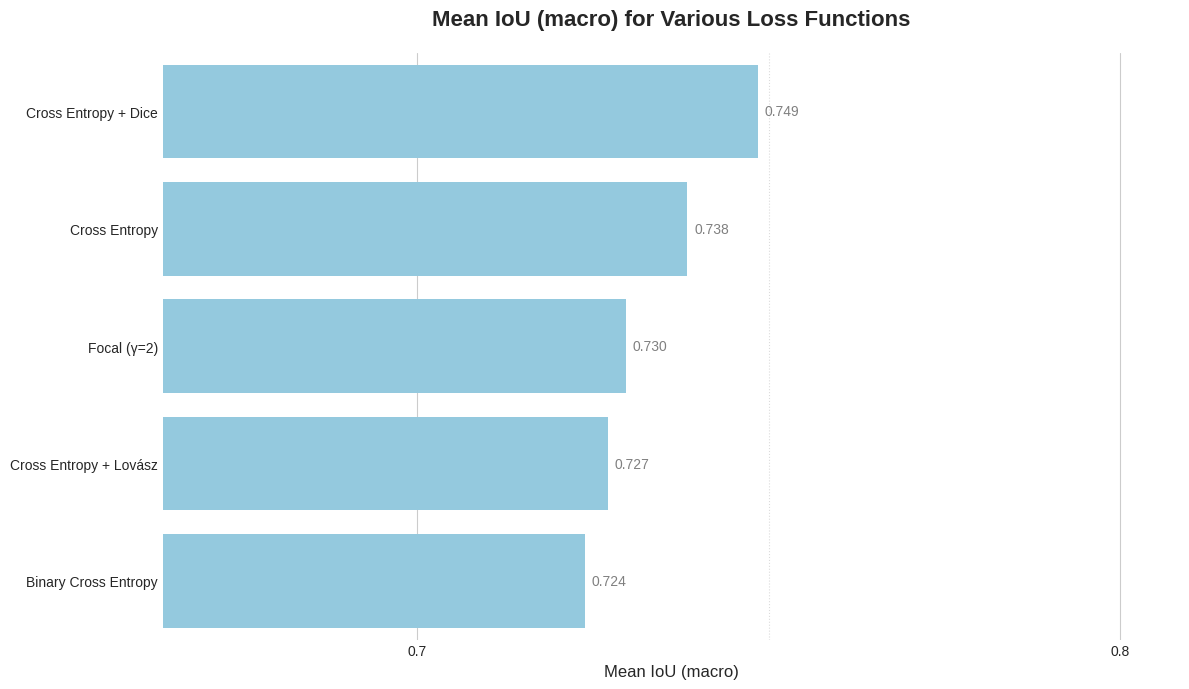

In [ ]:
HUMAN_READABLE_NAMES = {
    "coco_segmentation_ce_loss": "Cross Entropy",
    "coco_segmentation_bce_loss": "Binary Cross Entropy",
    "coco_segmentation_ce_dice_loss": "Cross Entropy + Dice",
    "coco_segmentation_focal_g2_loss": "Focal (γ=2)",
    "coco_segmentation_ce_lovasz_loss": "Cross Entropy + Lovász",
    "coco_segmentation_logcoshdice_loss": "Log(cosh(Dice))",
    "coco_segmentation_ce_focal_tversky_loss": "Cross Entropy + Focal Tversky",
}

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

def plot_mean_iou_bar_chart(df, title, save_path):
    df["run_name"] = df["run_name"].map(HUMAN_READABLE_NAMES).fillna(df["run_name"])
    # sort by mIoU_macro descending
    df = df.sort_values(by="mIoU_macro", ascending=False)

    # Set a professional plot style
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Create the horizontal bar plot
    bars = sns.barplot(
        x="mIoU_macro",
        y="run_name",
        data=df,
        color='skyblue',
        ax=ax
    )

    # Add data labels to each bar for precise values
    ax.bar_label(bars.containers[0], fmt='%.3f', padding=5, fontsize=10, color='gray')

    # --- Grid and Axis Customization ---
    # Set major grid lines every 0.1 and minor ones every 0.05
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.1))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.05))
    ax.grid(which='minor', axis='x', linestyle=':', alpha=0.7)

    # Set plot limits and labels
    # ax.set_xlim(left=min(df["mIoU_macro"]) - 0.06, right=max(df["mIoU_macro"]) + 0.06) # Auto-adjust x-limits
    ax.set_xlim(left=0.7, right=0.8) # Auto-adjust x-limits
    ax.set_title(title, fontsize=16, pad=20, weight='bold')
    ax.set_xlabel('Mean IoU (macro)', fontsize=12)
    ax.set_ylabel('') # The y-ticks are self-explanatory

    # Remove unnecessary chart borders (spines)
    sns.despine(left=True, bottom=True)
    
    # --- Final Touches ---
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_mean_iou_bar_chart(R_overall, "Mean IoU (macro) for Various Loss Functions", os.path.join(FIG_DIR, "mean_iou_bar_chart.png"))